In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
uploaded = files.upload()
df = pd.read_csv('Energy.csv')

Saving Energy.csv to Energy.csv


In [4]:
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [12]:
df.shape

(768, 10)

In [9]:
missing_values = df.isnull().sum()
duplicates = df.duplicated().sum()
summary = df.describe()
print("number of missing value:\n", missing_values)
print("\nnumber of duplicated", duplicates)
print("\nststic summary:\n", summary)

number of missing value:
 Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64

number of duplicated 0

ststic summary:
        Relative_Compactness  Surface_Area   Wall_Area   Roof_Area  \
count            768.000000    768.000000  768.000000  768.000000   
mean               0.764167    671.708333  318.500000  176.604167   
std                0.105777     88.086116   43.626481   45.165950   
min                0.620000    514.500000  245.000000  110.250000   
25%                0.682500    606.375000  294.000000  140.875000   
50%                0.750000    673.750000  318.500000  183.750000   
75%                0.830000    741.125000  343.000000  220.500000   
max                0.980000    808.500000  416.500000  22

In [10]:
df_filled = df.fillna(df.mean())

Q1 = df_filled.quantile(0.25)
Q3 = df_filled.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((df_filled < lower_bound) | (df_filled > upper_bound)).any(axis=1)
df_no_outliers = df_filled[~outliers]

print("Task 2 - Missing values after strategy:", df_filled.isnull().sum().sum())
print("Task 3 - Outliers detected:", outliers.sum())
print("Task 3 - Shape before:", df_filled.shape)
print("Task 3 - Shape after:", df_no_outliers.shape)

Task 2 - Missing values after strategy: 0
Task 3 - Outliers detected: 0
Task 3 - Shape before: (768, 10)
Task 3 - Shape after: (768, 10)


Task 4 - Min-Max Scaled Data (First 5 rows):
   Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
0              1.000000      0.000000   0.285714   0.000000             1.0   
1              1.000000      0.000000   0.285714   0.000000             1.0   
2              1.000000      0.000000   0.285714   0.000000             1.0   
3              1.000000      0.000000   0.285714   0.000000             1.0   
4              0.777778      0.166667   0.428571   0.111111             1.0   

   Orientation  Glazing_Area  Glazing_Area_Distribution  Heating_Load  \
0     0.000000           0.0                        0.0      0.257212   
1     0.333333           0.0                        0.0      0.257212   
2     0.666667           0.0                        0.0      0.257212   
3     1.000000           0.0                        0.0      0.257212   
4     0.000000           0.0                        0.0      0.399838   

   Cooling_Load  
0      0.280905  
1    

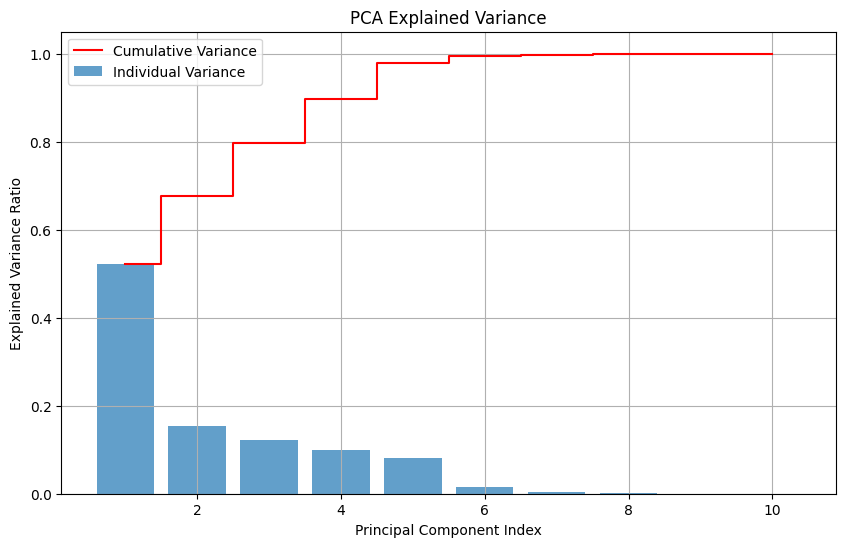

In [11]:
min_max_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(min_max_scaler.fit_transform(df_no_outliers), columns=df_no_outliers.columns)

z_scaler = StandardScaler()
df_zscore = pd.DataFrame(z_scaler.fit_transform(df_no_outliers), columns=df_no_outliers.columns)

print("Task 4 - Min-Max Scaled Data (First 5 rows):")
print(df_minmax.head())
print("\nTask 4 - Z-score Normalized Data (First 5 rows):")
print(df_zscore.head())

# Task 5: PCA and Interpreted Variance
pca = PCA()
pca_data = pca.fit_transform(df_zscore)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nTask 5 - Explained Variance Ratio per Component:")
print(explained_variance)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, label='Individual Variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative Variance', color='red')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid()
plt.show()

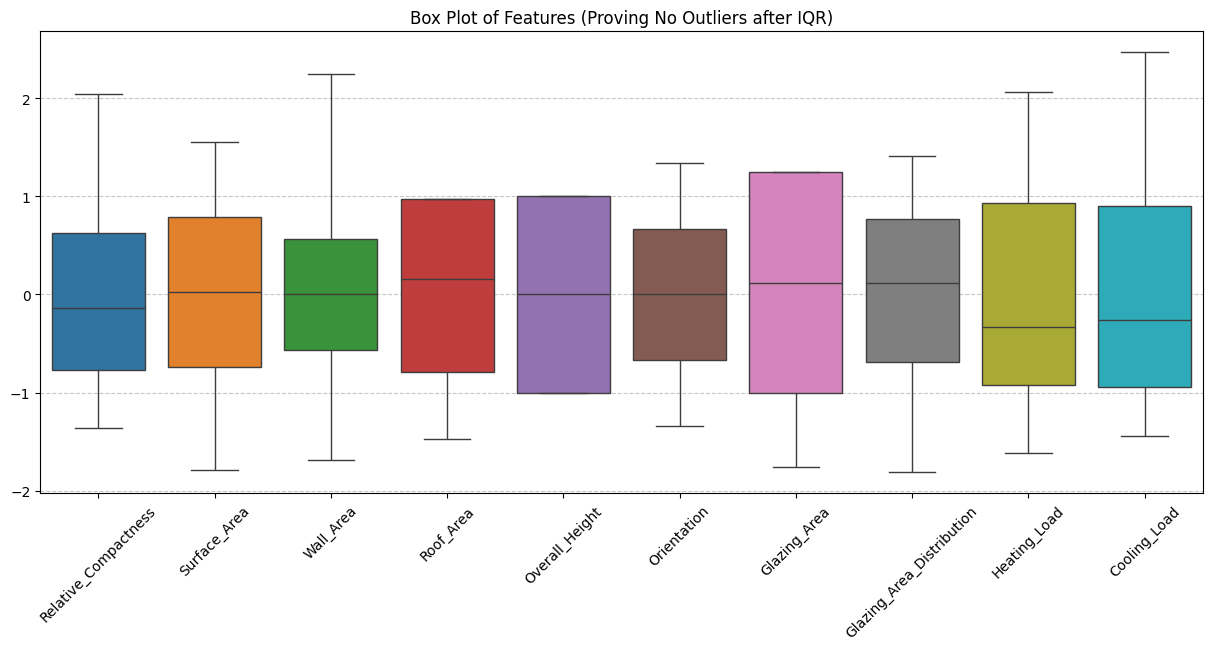

In [15]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_zscore)
plt.xticks(rotation=45)
plt.title('Box Plot of Features (Proving No Outliers after IQR)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()